# S&P 500 — LSTM multi-output, multi-step

Trains one LSTM on a rolling **OHLCV** window and predicts the next **H** normalized timesteps of **Close** and **High** as separate heads (multi-output, multi-step).

- **Dataset**: [camnugent/sandp500](https://www.kaggle.com/datasets/camnugent/sandp500) on Kaggle; locally via `kagglehub.dataset_download("camnugent/sandp500")` or a CSV under `data/sandp500/`.
- **Related**: [Stock market LSTM notebook (Faressayah)](https://www.kaggle.com/code/faressayah/stock-market-analysis-prediction-using-lstm), Keras [weather timeseries](https://keras.io/examples/timeseries/timeseries_weather_forecasting/) pattern.

This notebook is self-contained (load → windows → model → plots including a rolling-mean baseline).

## Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import keras

FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]

_CANONICAL_COL = {
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "adj close": "Adj Close",
    "adj_close": "Adj Close",
    "volume": "Volume",
    "name": "Name",
    "symbol": "Symbol",
    "ticker": "Symbol",
    "company_name": "Name",
    "company name": "Name",
}


def _normalize_ohlcv_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [_CANONICAL_COL.get(c.strip().lower(), c.strip()) for c in out.columns]
    return out


def _ticker_column(df: pd.DataFrame) -> str:
    for c in ("Name", "Symbol"):
        if c in df.columns:
            return c
    raise ValueError(
        "Need a ticker/name column (Name, Symbol, company_name, …). "
        f"Columns: {list(df.columns)}"
    )


def _is_kaggle() -> bool:
    return bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle").exists()


def _local_data_roots():
    cwd = Path.cwd()
    return [cwd, cwd / "standard-poors"]


def resolve_sandp500_csv() -> Path:
    """Kaggle input dirs → kagglehub cache → local data/sandp500 copy."""
    kaggle_roots = [
        Path("/kaggle/input/sandp500"),
        Path("/kaggle/input/camnugent-sandp500"),
        Path("/kaggle/input/sp500"),
    ]
    for root in kaggle_roots:
        if not root.is_dir():
            continue
        for name in ("all_stocks_5yr.csv", "all_stocks.csv"):
            p = root / name
            if p.is_file():
                return p
        found = list(root.rglob("all_stocks*.csv"))
        if found:
            return found[0]

    try:
        import kagglehub

        root = Path(kagglehub.dataset_download("camnugent/sandp500"))
        for name in ("all_stocks_5yr.csv", "all_stocks.csv"):
            p = root / name
            if p.is_file():
                return p
        found = list(root.rglob("all_stocks*.csv"))
        if found:
            return found[0]
    except Exception:
        pass

    for base in _local_data_roots():
        local = base / "data" / "sandp500"
        if local.is_dir():
            found = list(local.rglob("all_stocks*.csv")) + list(local.rglob("*.csv"))
            if found:
                return found[0]

    raise FileNotFoundError(
        "Could not find S&P 500 CSV. On Kaggle, add dataset camnugent/sandp500. "
        "Locally: pip install kagglehub and authenticate, or copy CSV under standard-poors/data/sandp500/."
    )


def load_ticker_ohlcv(csv_path: Path, ticker: str) -> pd.DataFrame:
    df = _normalize_ohlcv_frame(pd.read_csv(csv_path))
    name_col = _ticker_column(df)
    if "Date" not in df.columns:
        raise ValueError(f"Expected a date column; got {list(df.columns)}")

    needle = ticker.strip().upper()
    sub = df[df[name_col].astype(str).str.strip().str.upper() == needle].copy()
    if sub.empty:
        raise ValueError(
            f"No rows for ticker {ticker!r} in column {name_col!r}. "
            f"Sample values: {df[name_col].dropna().astype(str).unique()[:8].tolist()}"
        )

    sub["Date"] = pd.to_datetime(sub["Date"], utc=True, errors="coerce")
    sub = sub.sort_values("Date").reset_index(drop=True)

    for c in FEATURE_COLS:
        if c not in sub.columns:
            raise ValueError(f"Missing column {c}; columns are {list(sub.columns)}")

    return sub[FEATURE_COLS + ["Date"]]


def normalize(data: np.ndarray, train_split: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Z-score using mean/std from the first train_split rows only.

    Same pattern as the Keras weather timeseries example:
    https://keras.io/examples/timeseries/timeseries_weather_forecasting/
    """
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    data_std = np.where(data_std == 0, 1.0, data_std)
    return (data - data_mean) / data_std, data_mean, data_std


def build_arrays(df: pd.DataFrame, lookback: int, horizon: int, train_frac: float):
    """Return (x_train, y_train, x_val, y_val), scaler stats."""
    values = df[FEATURE_COLS].values.astype(np.float64)
    n = len(values)
    split = int(n * train_frac)
    if split <= lookback + horizon + 10:
        raise ValueError("Not enough rows for lookback, horizon, and split.")

    norm, mean, std = normalize(values, split)

    close_i = FEATURE_COLS.index("Close")
    high_i = FEATURE_COLS.index("High")

    def windows(start: int, end: int):
        xs, y_close, y_high = [], [], []
        last = end - lookback - horizon
        for i in range(start, last + 1):
            xs.append(norm[i : i + lookback])
            fut = norm[i + lookback : i + lookback + horizon]
            y_close.append(fut[:, close_i])
            y_high.append(fut[:, high_i])
        return (
            np.asarray(xs, dtype=np.float32),
            np.asarray(y_close, dtype=np.float32),
            np.asarray(y_high, dtype=np.float32),
        )

    train_end = split
    x_tr, c_tr, h_tr = windows(0, train_end)
    x_va, c_va, h_va = windows(split, n)

    y_tr = {"close": c_tr, "high": h_tr}
    y_va = {"close": c_va, "high": h_va}
    return (x_tr, y_tr, x_va, y_va), {"mean": mean, "std": std}


def make_model(lookback: int, n_features: int, horizon: int, lstm_units: int, lr: float):
    inputs = keras.layers.Input(shape=(lookback, n_features))
    x = keras.layers.LSTM(lstm_units)(inputs)
    x = keras.layers.Dropout(0.2)(x)
    out_close = keras.layers.Dense(horizon, name="close")(x)
    out_high = keras.layers.Dense(horizon, name="high")(x)
    model = keras.Model(inputs=inputs, outputs={"close": out_close, "high": out_high})
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={"close": "mse", "high": "mse"},
        loss_weights={"close": 1.0, "high": 0.5},
        metrics={"close": ["mae"], "high": ["mae"]},
    )
    return model


_IS_KAGGLE = _is_kaggle()
print("Kaggle kernel:", _IS_KAGGLE)

Kaggle kernel: False


## Load data (Kaggle path → kagglehub → local `data/sandp500`)


In [2]:
TICKERS = ["AAPL", "MSFT", "GOOG", "AMZN", "JPM"]
N_PLOT_SLICES = 3
LOOKBACK = int(os.environ.get("SNP_LOOKBACK", "60"))
HORIZON = int(os.environ.get("SNP_HORIZON", "5"))
TRAIN_FRAC = float(os.environ.get("SNP_TRAIN_FRAC", "0.8"))
BASELINE_WINDOW = int(os.environ.get("SNP_BASELINE_WINDOW", "7"))

csv_path = resolve_sandp500_csv()
print("Using CSV:", csv_path)

ohlcv_by_ticker = {t: load_ticker_ohlcv(csv_path, t) for t in TICKERS}
list(ohlcv_by_ticker.values())[0].tail()

/Users/nicapotato/Documents/repo/project/KaggleNotebooks/keras/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CSV: /Users/nicapotato/.cache/kagglehub/datasets/camnugent/sandp500/versions/4/all_stocks_5yr.csv


,Open,High,Low,Close,Volume,Date
1254,167.165,168.62,166.7600,167.78,47230787,2018-02-01 00:00:00+00:00
1255,166.000,166.80,160.1000,160.50,86593825,2018-02-02 00:00:00+00:00
1256,159.100,163.88,156.0000,156.49,72738522,2018-02-05 00:00:00+00:00
1257,154.830,163.72,154.0000,163.03,68243838,2018-02-06 00:00:00+00:00
1258,163.085,163.40,159.0685,159.54,51608580,2018-02-07 00:00:00+00:00


## Windows + multi-output targets

Each sample: shape `(lookback, 5)` for Open, High, Low, Close, Volume (z-scored on the train segment).  
Targets: `close` and `high` each `(horizon,)` in **normalized** space (same scaling as inputs).

In [3]:
data_by_ticker = {}
for ticker in TICKERS:
    data_by_ticker[ticker] = build_arrays(
        ohlcv_by_ticker[ticker], LOOKBACK, HORIZON, TRAIN_FRAC
    )
ticker = TICKERS[0]
(x_train, y_train, x_val, y_val), scaler = data_by_ticker[ticker]
print(f"Sample ({ticker}): x_train {x_train.shape}, x_val {x_val.shape}")

Sample (AAPL): x_train (943, 60, 5), x_val (188, 60, 5)


In [8]:
x_train[0]

array([[-1.58742607e+00, -1.59741652e+00, -1.53725314e+00,
        -1.54740095e+00, -2.95197040e-01],
       [-1.56458366e+00, -1.57086360e+00, -1.52199340e+00,
        -1.54360533e+00, -4.81180489e-01],
       [-1.52778184e+00, -1.51902211e+00, -1.49401712e+00,
        -1.48287582e+00, -1.25595570e-01],
       [-1.45798540e+00, -1.50132012e+00, -1.50673366e+00,
        -1.54107499e+00,  6.35100603e-01],
       [-1.57854295e+00, -1.52156353e+00, -1.52326500e+00,
        -1.47275424e+00,  1.10674873e-01],
       [-1.45798540e+00, -1.50005567e+00, -1.49783206e+00,
        -1.51577103e+00,  4.00282085e-01],
       [-1.48717296e+00, -1.47223830e+00, -1.42789161e+00,
        -1.44365478e+00,  4.62538779e-01],
       [-1.45798540e+00, -1.48994029e+00, -1.52453673e+00,
        -1.54993141e+00,  1.09195721e+00],
       [-1.57727385e+00, -1.62776279e+00, -1.59193397e+00,
        -1.59547853e+00,  1.04106963e+00],
       [-1.54935527e+00, -1.56959915e+00, -1.51817846e+00,
        -1.51197541e+00

## Model: shared LSTM + two `Dense(horizon)` heads

In [4]:
model_by_ticker = {}
for ticker in TICKERS:
    (x_train, y_train, x_val, y_val), _ = data_by_ticker[ticker]
    model_by_ticker[ticker] = make_model(
        LOOKBACK,
        len(FEATURE_COLS),
        HORIZON,
        lstm_units=64,
        lr=1e-3,
    )
model_by_ticker[TICKERS[0]].summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     17,920 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ close (Dense)       │ (None, 5)         │        325 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ high (Dense)        │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,570 (72.54 KB)

 Trainable params: 18,570 (72.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
BATCH_SIZE = 64
EPOCHS = 40

history_by_ticker = {}
for ticker in TICKERS:
    (x_train, y_train, x_val, y_val), _ = data_by_ticker[ticker]
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    )
    history_by_ticker[ticker] = model_by_ticker[ticker].fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=1,
    )
    n_ep = len(history_by_ticker[ticker].history["loss"])
    print(f"{ticker}: early stop / finished after {n_ep} epochs (max {EPOCHS})")

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - close_loss: 0.4040 - close_mae: 0.4973 - high_loss: 0.5891 - high_mae: 0.6130 - loss: 0.7055 - val_close_loss: 4.4611 - val_close_mae: 2.0348 - val_high_loss: 5.6930 - val_high_mae: 2.3074 - val_loss: 7.2257
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - close_loss: 0.1293 - close_mae: 0.2765 - high_loss: 0.1765 - high_mae: 0.3122 - loss: 0.2186 - val_close_loss: 3.7466 - val_close_mae: 1.8536 - val_high_loss: 3.4753 - val_high_mae: 1.7918 - val_loss: 5.4145
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - close_loss: 0.0877 - close_mae: 0.2263 - high_loss: 0.0875 - high_mae: 0.2236 - loss: 0.1321 - val_close_loss: 2.4165 - val_close_mae: 1.4613 - val_high_loss: 2.5532 - val_high_mae: 1.5211 - val_loss: 3.6376
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - close_loss: 0.0666 - close_mae: 0.1972 - high_loss: 0.0658 - high_mae: 0.1949 - loss: 0.0995 - val_close_loss: 1.8871 - val_close_mae: 1.2748 - val_high_loss: 2.210

## Loss curves

**Why some lines are shorter:** Training uses `EarlyStopping` on `val_loss` with `patience=10`. As soon as validation loss does not beat the best value for 10 epochs in a row, training stops (up to `EPOCHS`). That moment differs per ticker: e.g. AAPL’s `val_loss` may keep improving slowly (noisy or gentler overfitting), while another ticker’s `val_loss` flattens or worsens earlier, so stopping happens sooner. This is **not** a train/validation stratification issue — for time series you should keep a **chronological** split (first 80% train, last 20% validation); shuffling or “stratifying” would leak future prices into training.

To compare tickers on the same x-axis length, raise `patience`, set `EPOCHS` higher, or temporarily remove early stopping for exploration only.

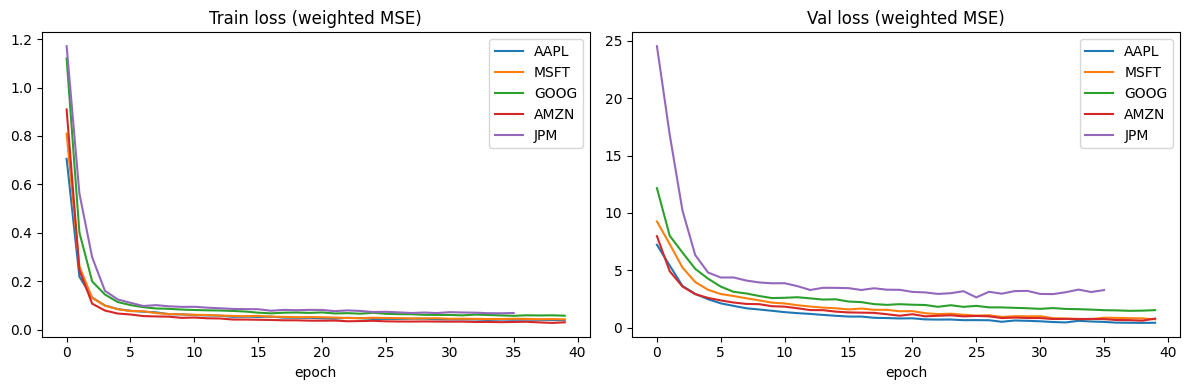

In [6]:
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(12, 4))
for ticker in TICKERS:
    h = history_by_ticker[ticker].history
    ax_train.plot(h["loss"], label=ticker)
    ax_val.plot(h["val_loss"], label=ticker)
ax_train.set_title("Train loss (weighted MSE)")
ax_val.set_title("Val loss (weighted MSE)")
ax_train.legend()
ax_val.legend()
ax_train.set_xlabel("epoch")
ax_val.set_xlabel("epoch")
plt.tight_layout()
plt.show()

## Qualitative check: train history, forecast, rolling-mean baseline

- **Top**: Train-period Close plus the LSTM **input window** (last `LOOKBACK` bars) for a chosen validation sample; dashed line at the temporal train/test split.
- **Bottom**: Next `HORIZON` bars — **actual** Close, **LSTM** prediction, and **baseline**: constant forecast = mean Close over the last `BASELINE_WINDOW` bars before the horizon (same ticker, evaluated at that sample’s forecast origin).

Validation MAE over all test windows compares the model to this baseline.

AAPL Val MAE: model=9.7891 USD | rolling-20 baseline=4.7254 USD


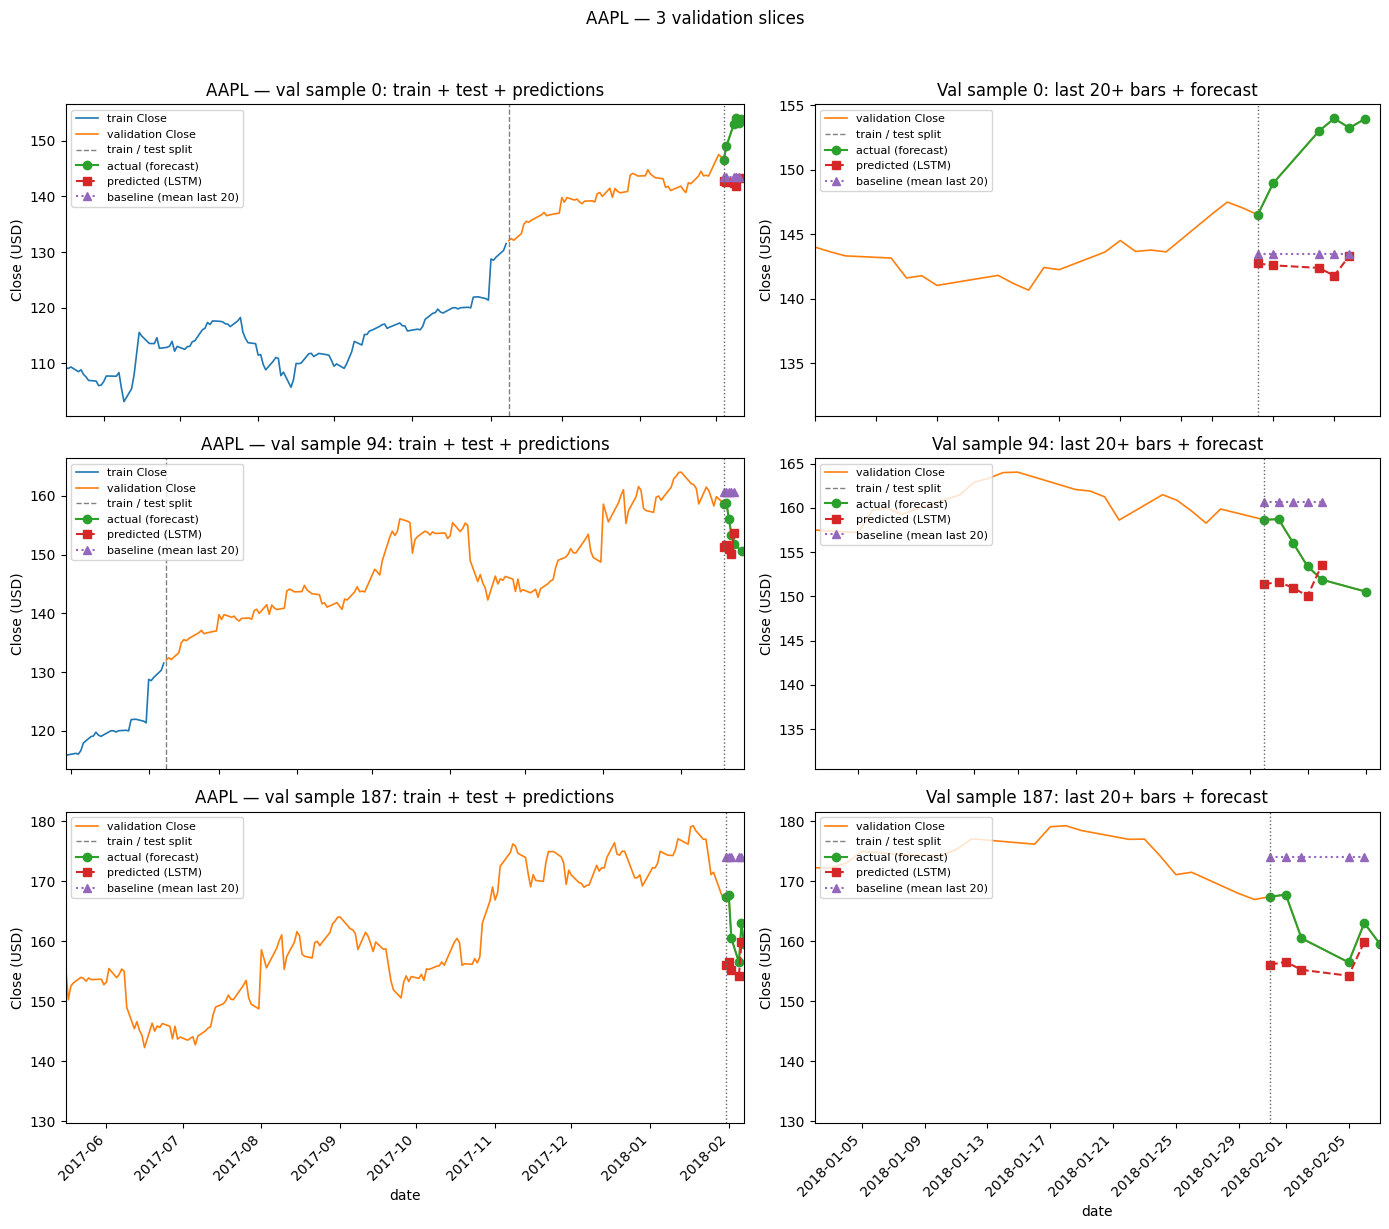

MSFT Val MAE: model=4.6949 USD | rolling-20 baseline=1.9111 USD


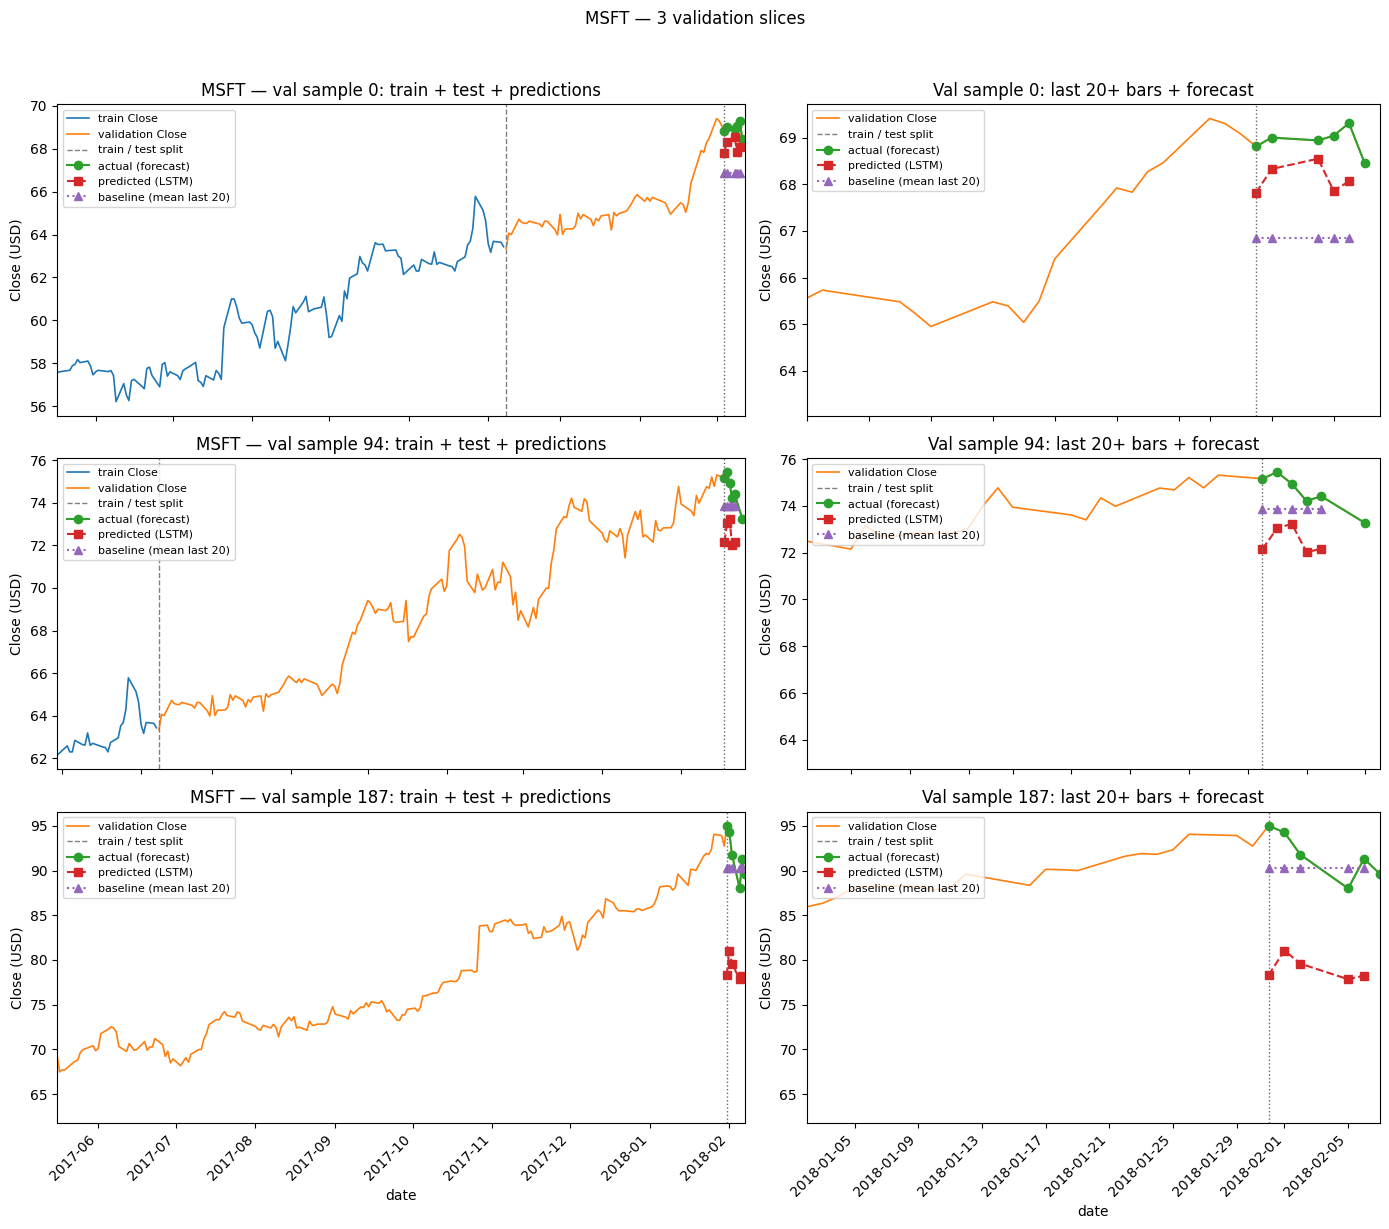

GOOG Val MAE: model=83.8036 USD | rolling-20 baseline=27.4462 USD


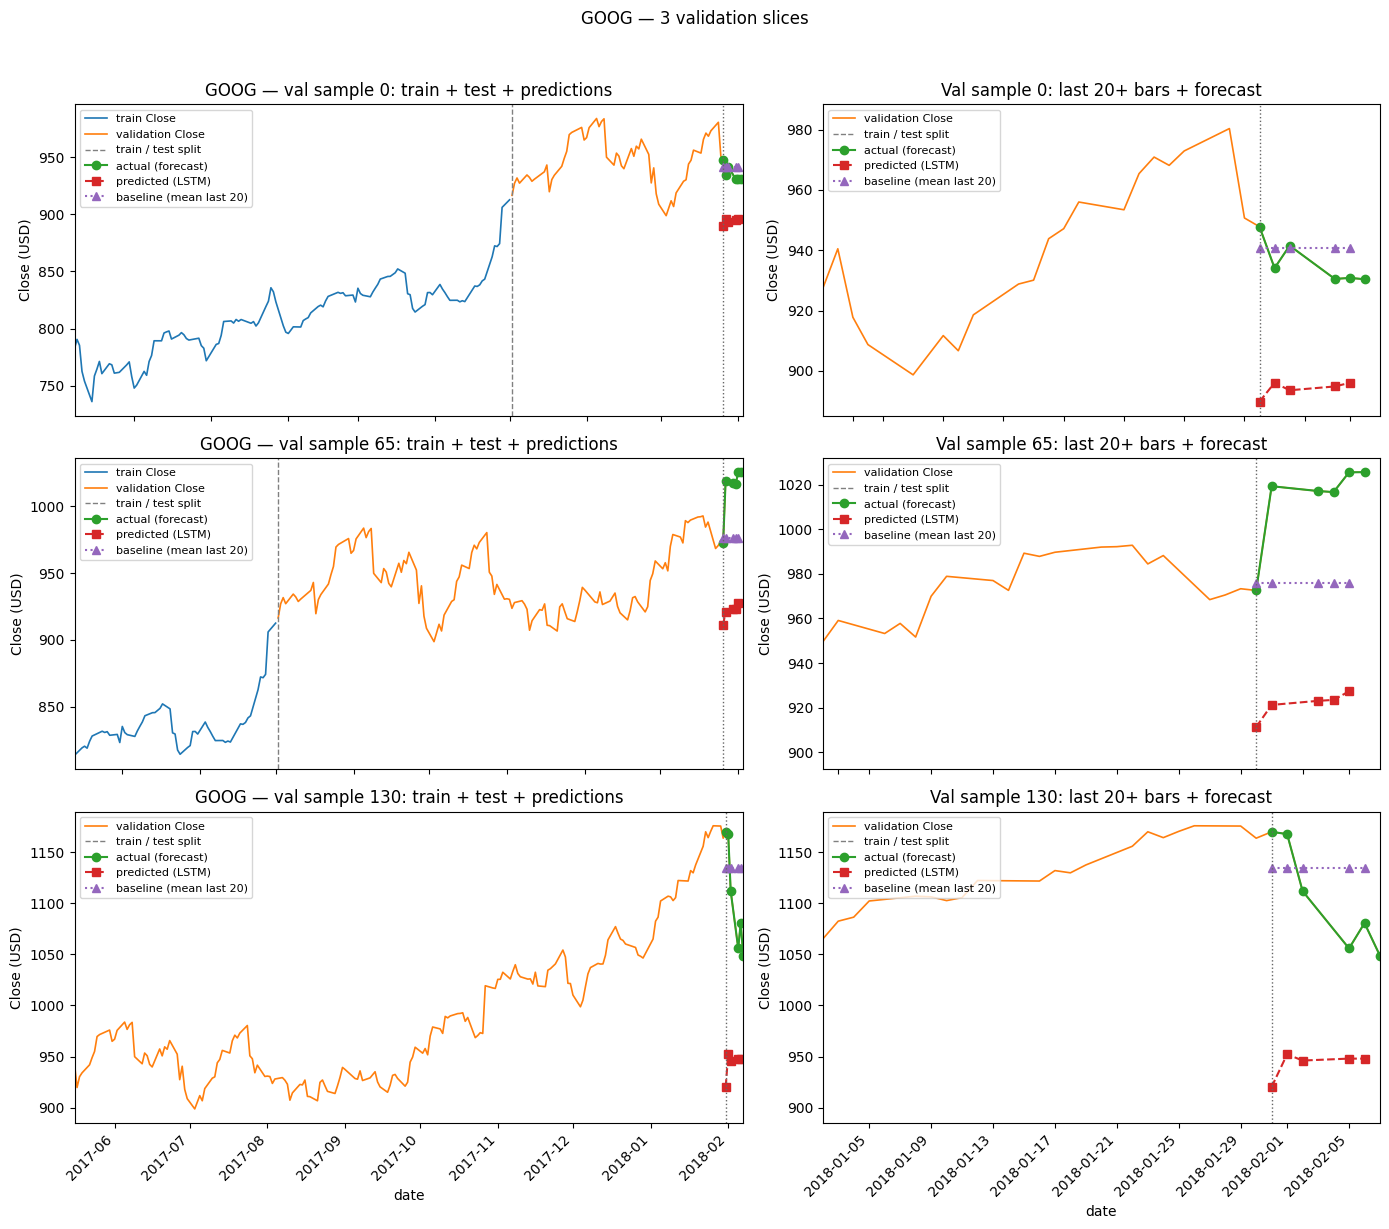

AMZN Val MAE: model=83.5943 USD | rolling-20 baseline=41.1123 USD


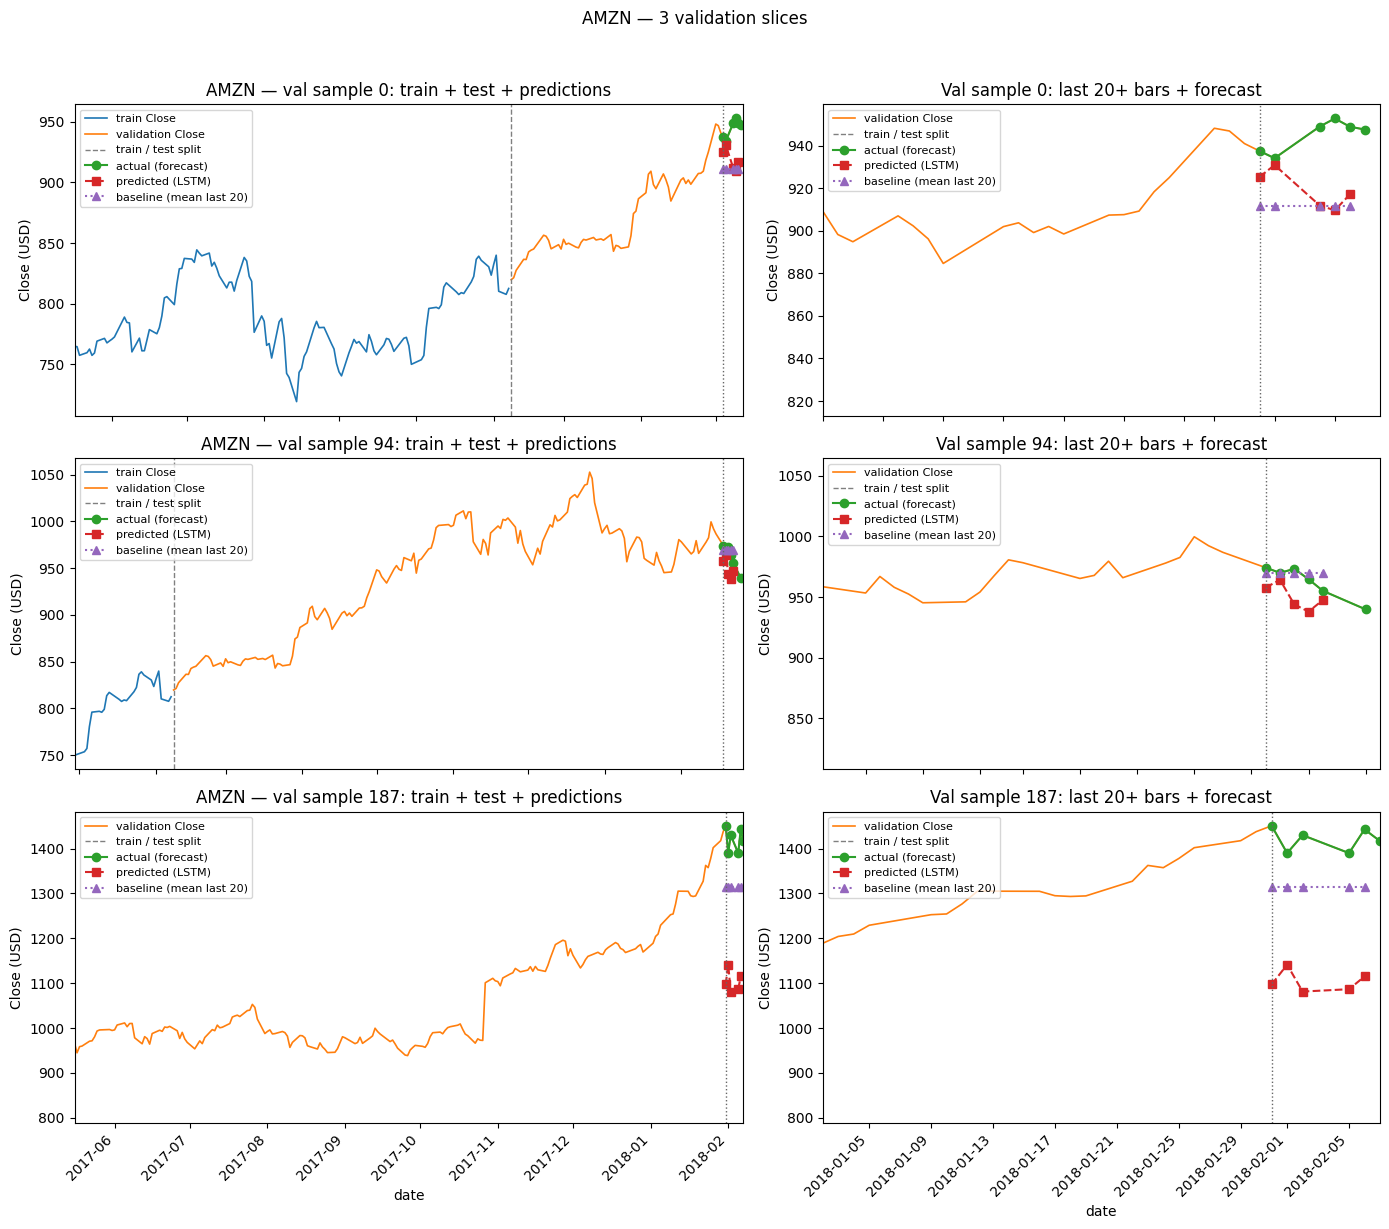

JPM Val MAE: model=7.7561 USD | rolling-20 baseline=2.7033 USD


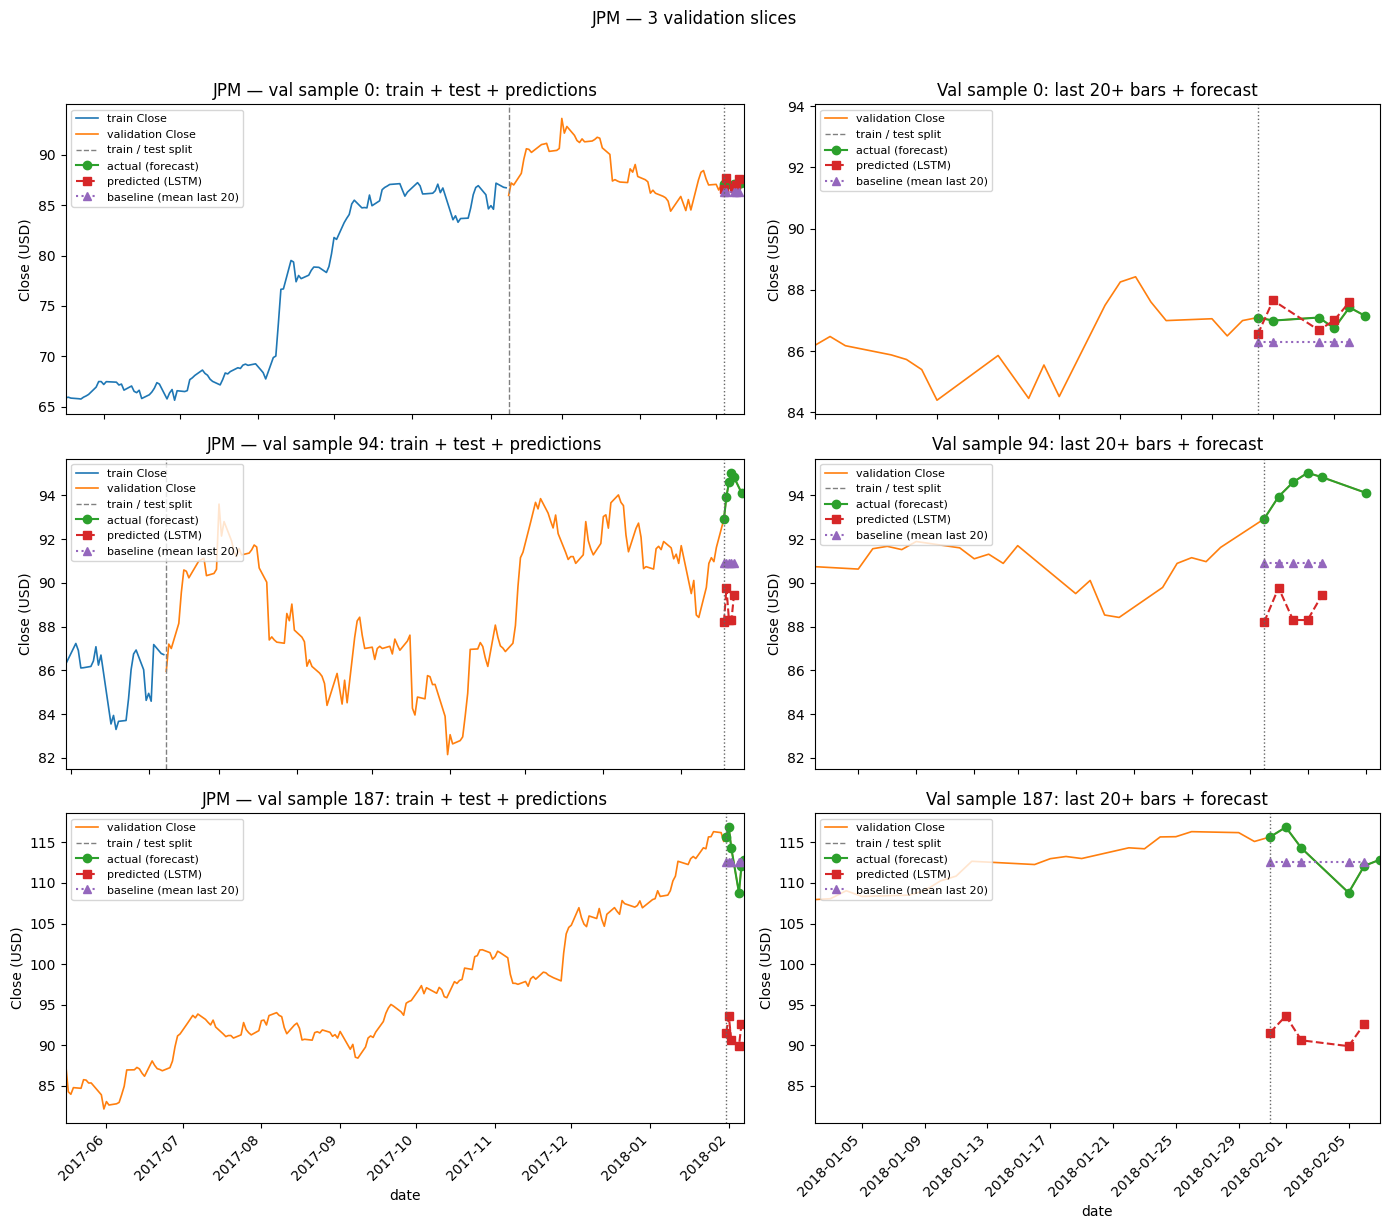

In [7]:
close_i = FEATURE_COLS.index("Close")


def close_baseline_for_val_index(ohlcv: pd.DataFrame, split: int, idx: int) -> np.ndarray:
    """Per-sample baseline: repeat rolling mean of Close over last BASELINE_WINDOW bars at forecast start."""
    i = split + idx
    end_lookback = i + LOOKBACK - 1
    lo = max(0, end_lookback - BASELINE_WINDOW + 1)
    b = float(ohlcv["Close"].iloc[lo : end_lookback + 1].mean())
    return np.full(HORIZON, b, dtype=np.float64)


for ticker in TICKERS:
    ohlcv = ohlcv_by_ticker[ticker]
    (x_train, y_train, x_val, y_val), scaler = data_by_ticker[ticker]
    mean, std = scaler["mean"], scaler["std"]
    n_bars = len(ohlcv)
    split = int(n_bars * TRAIN_FRAC)

    pred_val = model_by_ticker[ticker].predict(x_val, verbose=0)
    pred_c_all = pred_val["close"] * std[close_i] + mean[close_i]
    true_c_all = y_val["close"] * std[close_i] + mean[close_i]
    base_all = np.stack(
        [close_baseline_for_val_index(ohlcv, split, j) for j in range(len(x_val))]
    )
    mae_model = float(np.mean(np.abs(pred_c_all - true_c_all)))
    mae_base = float(np.mean(np.abs(base_all - true_c_all)))
    print(
        f"{ticker} Val MAE: model={mae_model:.4f} USD | "
        f"rolling-{BASELINE_WINDOW} baseline={mae_base:.4f} USD"
    )

    n_val = len(x_val)
    plot_indices = (
        [0, n_val // 2, n_val - 1]
        if n_val >= 3
        else list(range(min(n_val, N_PLOT_SLICES)))
    )

    N_CONTEXT_BARS = 20
    fig, axes = plt.subplots(
        N_PLOT_SLICES,
        2,
        figsize=(14, 4 * N_PLOT_SLICES),
        gridspec_kw={"width_ratios": [1.2, 1]},
        sharex=False,
        sharey=False,
    )
    close = ohlcv["Close"]
    dates = ohlcv["Date"]

    for row, idx in enumerate(plot_indices[:N_PLOT_SLICES]):
        ax_main, ax_ctx = axes[row, 0], axes[row, 1]
        i = split + idx

        pred_c = pred_val["close"][idx] * std[close_i] + mean[close_i]
        true_c = y_val["close"][idx] * std[close_i] + mean[close_i]
        baseline_c = close_baseline_for_val_index(ohlcv, split, idx)

        x0_line = i + LOOKBACK - 1
        lo = max(0, i - 2 * LOOKBACK)
        hi = min(n_bars, x0_line + HORIZON + 1)
        if lo < split:
            t_train = dates.iloc[lo:split]
            close_train = close.iloc[lo:split]
            ax_main.plot(t_train, close_train, color="C0", linewidth=1.2, label="train Close")
        t_val = dates.iloc[split:hi]
        close_val = close.iloc[split:hi]
        ax_main.plot(t_val, close_val, color="C1", linewidth=1.2, label="validation Close")
        ax_main.axvline(
            dates.iloc[split], color="0.5", linestyle="--", linewidth=1, label="train / test split"
        )
        t_fut = dates.iloc[x0_line : x0_line + HORIZON]
        xf = dates.iloc[x0_line : x0_line + HORIZON + 1]
        y_bridge = np.concatenate([[close.iloc[x0_line]], true_c])
        ax_main.plot(xf, y_bridge, "o-", color="C2", label="actual (forecast)", markersize=6)
        ax_main.plot(t_fut, pred_c, "s--", color="C3", label="predicted (LSTM)")
        ax_main.plot(t_fut, baseline_c, "^:", color="C4", label=f"baseline (mean last {BASELINE_WINDOW})")
        ax_main.axvline(dates.iloc[x0_line], color="0.4", linestyle=":", linewidth=1)
        ax_main.set_ylabel("Close (USD)")
        ax_main.set_xlabel("date")
        ax_main.set_title(f"{ticker} — val sample {idx}: train + test + predictions")
        ax_main.legend(loc="upper left", fontsize=8)
        ax_main.set_xlim(dates.iloc[lo], dates.iloc[min(n_bars - 1, x0_line + HORIZON + 1)])

        lo_ctx = max(0, x0_line - N_CONTEXT_BARS)
        hi_ctx = min(n_bars, x0_line + HORIZON + 1)
        if lo_ctx < split:
            t_train_ctx = dates.iloc[lo_ctx:split]
            close_train_ctx = close.iloc[lo_ctx:split]
            ax_ctx.plot(t_train_ctx, close_train_ctx, color="C0", linewidth=1.2, label="train Close")
        t_val_ctx = dates.iloc[split:hi_ctx]
        close_val_ctx = close.iloc[split:hi_ctx]
        ax_ctx.plot(t_val_ctx, close_val_ctx, color="C1", linewidth=1.2, label="validation Close")
        ax_ctx.axvline(
            dates.iloc[split], color="0.5", linestyle="--", linewidth=1, label="train / test split"
        )
        ax_ctx.plot(xf, y_bridge, "o-", color="C2", label="actual (forecast)", markersize=6)
        ax_ctx.plot(t_fut, pred_c, "s--", color="C3", label="predicted (LSTM)")
        ax_ctx.plot(t_fut, baseline_c, "^:", color="C4", label=f"baseline (mean last {BASELINE_WINDOW})")
        ax_ctx.axvline(dates.iloc[x0_line], color="0.4", linestyle=":", linewidth=1)
        ax_ctx.set_ylabel("Close (USD)")
        ax_ctx.set_xlabel("date")
        ax_ctx.set_title(f"Val sample {idx}: last {N_CONTEXT_BARS}+ bars + forecast")
        ax_ctx.legend(loc="upper left", fontsize=8)
        ax_ctx.set_xlim(dates.iloc[lo_ctx], dates.iloc[min(n_bars - 1, x0_line + HORIZON + 1)])

    fig.autofmt_xdate(rotation=45)
    plt.suptitle(f"{ticker} — {N_PLOT_SLICES} validation slices", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()